In [ ]:
!pip install geopandas geop/y shapely

ERROR: Invalid requirement: 'geop/y': Expected end or semicolon (after name and no valid version specifier)
    geop/y
        ^
Hint: It looks like a path. File 'geop/y' does not exist.


In [ ]:
import pandas as pd
import re

import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import geopandas as gpd
from geopy.geocoders import Nominatim
from shapely.geometry import Point
import time

In [ ]:
data = {
'Text': [
"Great meeting with @user1 today!",
"Thanks @user2 and @user1 for the support!",
"@user3 is doing amazing work!",
"Follow @user2 and @user4 for updates",
"@user1 @user2 @user3 are top contributors!"
]
}

df = pd.DataFrame(data)
print(df)

                                         Text
0            Great meeting with @user1 today!
1   Thanks @user2 and @user1 for the support!
2               @user3 is doing amazing work!
3        Follow @user2 and @user4 for updates
4  @user1 @user2 @user3 are top contributors!


In [ ]:
def extract_mentions(text):
  return re.findall(r'@\w+', text)
df['Mentions'] = df['Text'].apply(extract_mentions)
print(df[['Text', 'Mentions']])

                                         Text                  Mentions
0            Great meeting with @user1 today!                  [@user1]
1   Thanks @user2 and @user1 for the support!          [@user2, @user1]
2               @user3 is doing amazing work!                  [@user3]
3        Follow @user2 and @user4 for updates          [@user2, @user4]
4  @user1 @user2 @user3 are top contributors!  [@user1, @user2, @user3]


In [ ]:
all_mentions = [mention for sublist in df['Mentions'] for mention in sublist]
mention_count = Counter(all_mentions)
mention_df = pd.DataFrame(mention_count.items(), columns=['User', 'Count'])
mention_df = mention_df.sort_values(by='Count', ascending=False)
print(mention_df)

     User  Count
0  @user1      3
1  @user2      3
2  @user3      2
3  @user4      1


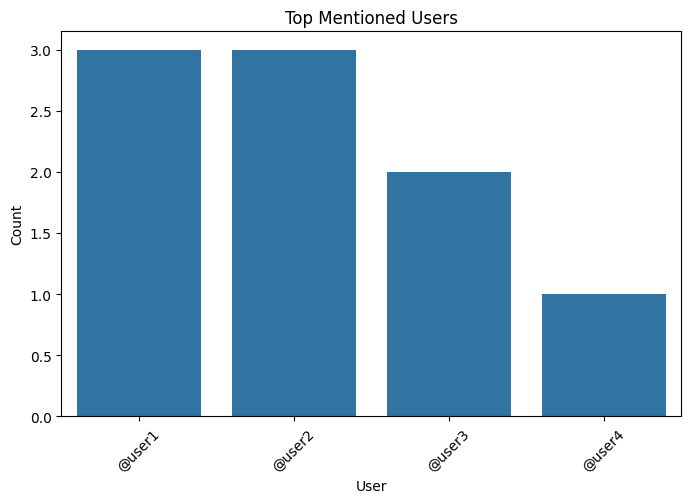

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(x='User', y='Count', data=mention_df)
plt.title("Top Mentioned Users")
plt.xticks(rotation=45)
plt.show()

In [ ]:
location_data = {
'Review': [
"Good product", "Excellent service", "Average experience",
"Not satisfied", "Loved it!"
],
'Location': [
"Mumbai", "Delhi", "New York", "London", "Tokyo"
]
}

loc_df = pd.DataFrame(location_data)
print(loc_df)

               Review  Location
0        Good product    Mumbai
1   Excellent service     Delhi
2  Average experience  New York
3       Not satisfied    London
4           Loved it!     Tokyo


In [ ]:
geolocator = Nominatim(user_agent="geo_app")
def get_coordinates(location):
  try:
    loc = geolocator.geocode(location)
    time.sleep(1) # avoid API blocking
    if loc:
      return loc.latitude, loc.longitude
    else:
      return None, None
  except:
    return None, None
loc_df[['Latitude', 'Longitude']] = loc_df['Location'].apply(
lambda x: pd.Series(get_coordinates(x))
)
print(loc_df)

               Review  Location   Latitude   Longitude
0        Good product    Mumbai  19.054999   72.869203
1   Excellent service     Delhi  28.613895   77.209006
2  Average experience  New York  40.712728  -74.006015
3       Not satisfied    London  51.507446   -0.127765
4           Loved it!     Tokyo  35.676860  139.763895


In [ ]:
geometry = [Point(xy) for xy in zip(loc_df['Longitude'], loc_df['Latitude'])]
geo_df = gpd.GeoDataFrame(loc_df, geometry=geometry)
geo_df = geo_df.dropna()

In [ ]:
import geopandas as gpd
# Load world map from online source
world = gpd.read_file("https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip")

<Figure size 1000x600 with 0 Axes>

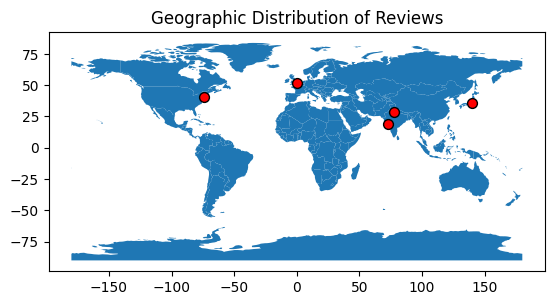

In [ ]:
plt.figure(figsize=(10,6))
ax = world.plot()
geo_df.plot(ax=ax, markersize=50, color='red', edgecolor='black', alpha=1)
plt.title("Geographic Distribution of Reviews")
plt.show()

# Exercise 1

In [ ]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

In [ ]:
data = {
    'Text': [
        "Excited about deep learning! #DeepLearning #AI",
        "Analyzing datasets all day #DataAnalytics #BigData",
        "Building cool projects with Python #Python #Dev",
        "AI is transforming the future #AI #Innovation",
        "Coding and debugging fun #Programming #Coding",
        "Understanding neural networks #DeepLearning #ML",
        "Visualizing data insights #DataViz #Analytics",
        "Automation using Python scripts #Python #Automation",
        "Tech trends to watch #Technology #AI",
        "Sharpening coding skills daily #Coding #Developer"
    ]
}
df = pd.DataFrame(data)
print(df)

                                                Text
0     Excited about deep learning! #DeepLearning #AI
1  Analyzing datasets all day #DataAnalytics #Big...
2    Building cool projects with Python #Python #Dev
3      AI is transforming the future #AI #Innovation
4      Coding and debugging fun #Programming #Coding
5    Understanding neural networks #DeepLearning #ML
6      Visualizing data insights #DataViz #Analytics
7  Automation using Python scripts #Python #Autom...
8               Tech trends to watch #Technology #AI
9  Sharpening coding skills daily #Coding #Developer


In [ ]:
def extract_hashtags(text):
  return re.findall(r'#\w+', text)
df['Hashtags'] = df['Text'].apply(extract_hashtags)
print(df[['Text', 'Hashtags']])

                                                Text  \
0     Excited about deep learning! #DeepLearning #AI   
1  Analyzing datasets all day #DataAnalytics #Big...   
2    Building cool projects with Python #Python #Dev   
3      AI is transforming the future #AI #Innovation   
4      Coding and debugging fun #Programming #Coding   
5    Understanding neural networks #DeepLearning #ML   
6      Visualizing data insights #DataViz #Analytics   
7  Automation using Python scripts #Python #Autom...   
8               Tech trends to watch #Technology #AI   
9  Sharpening coding skills daily #Coding #Developer   

                     Hashtags  
0        [#DeepLearning, #AI]  
1  [#DataAnalytics, #BigData]  
2             [#Python, #Dev]  
3          [#AI, #Innovation]  
4     [#Programming, #Coding]  
5        [#DeepLearning, #ML]  
6      [#DataViz, #Analytics]  
7      [#Python, #Automation]  
8          [#Technology, #AI]  
9       [#Coding, #Developer]  


In [ ]:
all_tags = [tag for sublist in df['Hashtags'] for tag in sublist]
tag_count = Counter(all_tags)
tag_df = pd.DataFrame(tag_count.items(), columns=['Hashtag', 'Count'])
tag_df = tag_df.sort_values(by='Count', ascending=False)
print(tag_df)

           Hashtag  Count
1              #AI      3
0    #DeepLearning      2
4          #Python      2
8          #Coding      2
2   #DataAnalytics      1
5             #Dev      1
3         #BigData      1
6      #Innovation      1
7     #Programming      1
9              #ML      1
10        #DataViz      1
11      #Analytics      1
12     #Automation      1
13     #Technology      1
14      #Developer      1


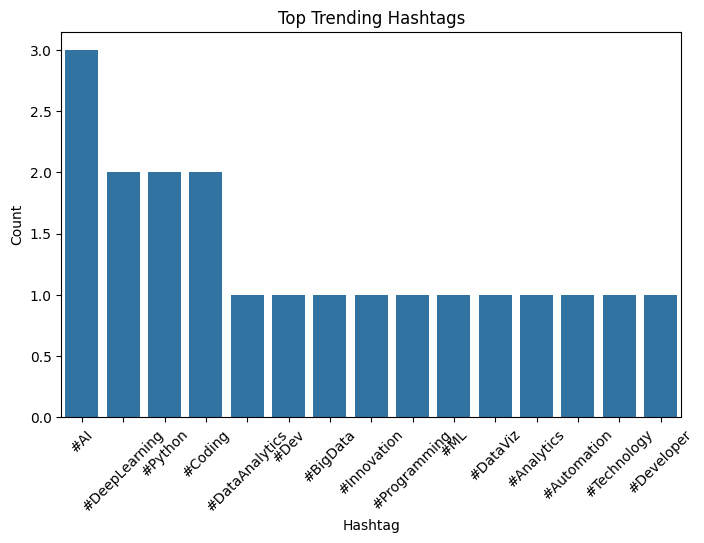

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(x='Hashtag', y='Count', data=tag_df)
plt.title("Top Trending Hashtags")
plt.xticks(rotation=45)
plt.show()

# Exercise 2

In [ ]:
!pip install textblob

In [ ]:
import pandas as pd
from textblob import TextBlob
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
data = {
    'Review': [
        "Amazing service, highly recommend",
        "Terrible quality, not worth it",
        "It was okay, nothing special",
        "Really impressed with the product",
        "Very poor experience, will not return"
    ],
    'Location': [
        "Bangalore", "Pune", "Bangalore", "Chennai", "Pune"
    ]
}
df = pd.DataFrame(data)
print(df)

                                  Review   Location
0      Amazing service, highly recommend  Bangalore
1         Terrible quality, not worth it       Pune
2           It was okay, nothing special  Bangalore
3      Really impressed with the product    Chennai
4  Very poor experience, will not return       Pune


In [ ]:
def get_sentiment(text):
  polarity = TextBlob(text).sentiment.polarity
  if polarity > 0:
      return "Positive"
  elif polarity < 0:
    return "Negative"
  else:
    return "Neutral"
df['Sentiment'] = df['Review'].apply(get_sentiment)
print(df)

                                  Review   Location Sentiment
0      Amazing service, highly recommend  Bangalore  Positive
1         Terrible quality, not worth it       Pune  Negative
2           It was okay, nothing special  Bangalore  Positive
3      Really impressed with the product    Chennai  Positive
4  Very poor experience, will not return       Pune  Negative


In [ ]:
sentiment_count = df.groupby(['Location', 'Sentiment']).size().unstack().fillna(0)
print(sentiment_count)

Sentiment  Negative  Positive
Location                     
Bangalore       0.0       2.0
Chennai         0.0       1.0
Pune            2.0       0.0


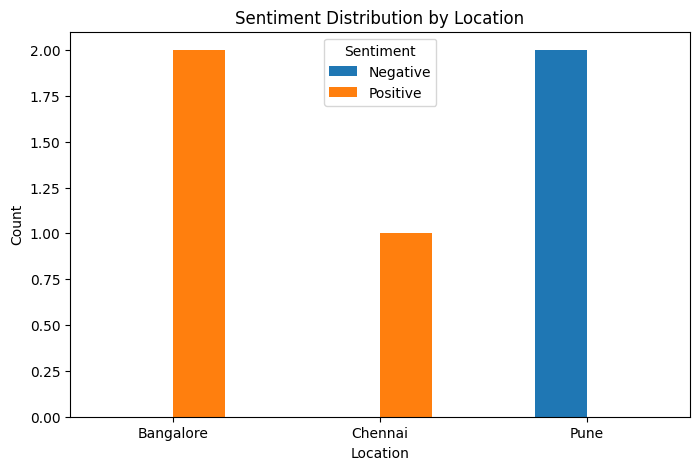

In [ ]:
sentiment_count.plot(kind='bar', figsize=(8,5))
plt.title("Sentiment Distribution by Location")
plt.xlabel("Location")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

/tmp/ipykernel_2182/3920963515.py:23: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  geo_sentiment_df[geo_sentiment_df['Sentiment'] == 'Neutral'].plot(


<Figure size 1200x800 with 0 Axes>

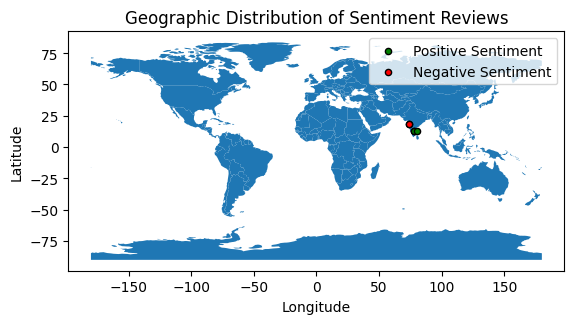

In [ ]:
# Geocode locations for the sentiment analysis data
sentiment_df = df.copy()
sentiment_df[['Latitude', 'Longitude']] = sentiment_df['Location'].apply(
    lambda x: pd.Series(get_coordinates(x))
)

# Create a GeoDataFrame for the sentiment data
geometry_sentiment = [Point(xy) for xy in zip(sentiment_df['Longitude'], sentiment_df['Latitude'])]
geo_sentiment_df = gpd.GeoDataFrame(sentiment_df, geometry=geometry_sentiment)
geo_sentiment_df = geo_sentiment_df.dropna() # Drop rows where geocoding failed

# Plot the world map and overlay sentiment locations
plt.figure(figsize=(12, 8))
ax = world.plot() # Removed explicit color='lightgray' to use default blueish map

# Plot sentiments with different colors
geo_sentiment_df[geo_sentiment_df['Sentiment'] == 'Positive'].plot(
    ax=ax, markersize=20, color='green', edgecolor='black', alpha=1, label='Positive Sentiment'
)
geo_sentiment_df[geo_sentiment_df['Sentiment'] == 'Negative'].plot(
    ax=ax, markersize=20, color='red', edgecolor='black', alpha=1, label='Negative Sentiment'
)
geo_sentiment_df[geo_sentiment_df['Sentiment'] == 'Neutral'].plot(
    ax=ax, markersize=20, color='blue', edgecolor='black', alpha=1, label='Neutral Sentiment'
)

plt.title("Geographic Distribution of Sentiment Reviews")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()
plt.show()

/tmp/ipykernel_2182/3235467960.py:13: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  geo_sentiment_df[geo_sentiment_df['Sentiment'] == 'Neutral'].plot(


<Figure size 1200x800 with 0 Axes>

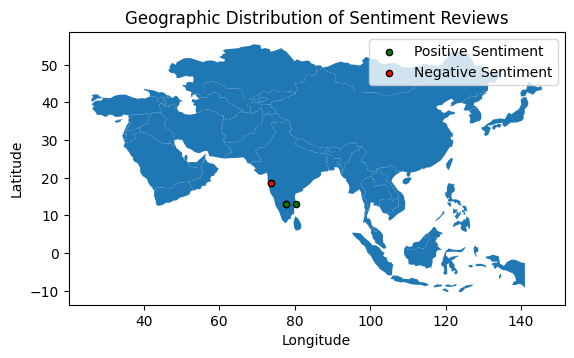

In [ ]:
world_asia = world[world['CONTINENT'] == 'Asia']

plt.figure(figsize=(12, 8))
ax = world_asia.plot()

# Plot sentiments with different colors
geo_sentiment_df[geo_sentiment_df['Sentiment'] == 'Positive'].plot(
    ax=ax, markersize=20, color='green', edgecolor='black', alpha=1, label='Positive Sentiment'
)
geo_sentiment_df[geo_sentiment_df['Sentiment'] == 'Negative'].plot(
    ax=ax, markersize=20, color='red', edgecolor='black', alpha=1, label='Negative Sentiment'
)
geo_sentiment_df[geo_sentiment_df['Sentiment'] == 'Neutral'].plot(
    ax=ax, markersize=20, color='blue', edgecolor='black', alpha=1, label='Neutral Sentiment'
)

plt.title("Geographic Distribution of Sentiment Reviews")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()
plt.show()